In [1]:
import glob
import time
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import astropy
import astropy.cosmology
import matplotlib
from matplotlib import pyplot as plt

from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.mocks.DDrppi_mocks import DDrppi_mocks
from Corrfunc.utils import convert_3d_counts_to_cf
from Corrfunc.utils import convert_rp_pi_counts_to_wp

import sys
sys.path.insert(0,'../code')
import utils
import correlations
import maps

%load_ext autoreload
%autoreload 2

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18

matplotlib.rc('text', usetex=False)

# wtheta

In [3]:
zmin, zmax = 0.8, 2.1
N_mocks = 5

mock_paths_all = sorted(glob.glob('../data/mocks_quaia/mock_catalog_quaia_G20.5_mock*.fits'))
print(f'Found {len(mock_paths_all)} mock files in data/mocks_quaia')
N_use = min(N_mocks, len(mock_paths_all))
if N_use < N_mocks:
    print(f'Warning: requested N={N_mocks} but only {N_use} available; using {N_use}.')
mock_paths = mock_paths_all[:N_use]
if N_use == 0:
    raise RuntimeError('No mock catalogs found in ../data/mocks_quaia/')
for p in mock_paths:
    print('  ', p)

# Real data in the same z-bin
G_max = 20.5
tag_quaia_zclust = '_zmin0.8zmax2.1'
tab_data = Table.read(f'../data/quaia_G{G_max}{tag_quaia_zclust}.fits')
print('Real-data columns:', tab_data.columns)
print('N real data =', len(tab_data))

# Randoms matched to the same z-bin
tab_rand = Table.read('../data/randoms/random_G20.5_zmin0.8zmax2.1_10x.fits')
print('Random columns:', tab_rand.columns)
print('N random =', len(tab_rand))

Found 10 mock files in data/mocks_quaia
   ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock1.fits
   ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock10.fits
   ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock2.fits
   ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock3.fits
   ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock4.fits
Real-data columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N real data = 814561
Random columns: <TableColumns names=('ra','dec','ebv')>
N random = 8141884


In [4]:
ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
ra_data, dec_data = tab_data['ra'], tab_data['dec']

theta_edges = np.logspace(-2.5, -0.25, 16)
theta = (theta_edges[1:] + theta_edges[:-1]) / 2
nthreads = 16
print(theta_edges)

# Compute RR(theta) once (shared by data + mocks)
start = time.time()
RR_theta = DDtheta_mocks(1, nthreads, theta_edges, ra_rand, dec_rand)
print(f'RR theta time (shared): {time.time()-start:.4f} s')

N_rand = len(ra_rand)

[0.00316228 0.00446684 0.00630957 0.00891251 0.01258925 0.01778279
 0.02511886 0.03548134 0.05011872 0.07079458 0.1        0.14125375
 0.19952623 0.28183829 0.39810717 0.56234133]


[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


RR theta time (shared): 21.2222 s


In [5]:
# Real data DD/DR + w(theta)
start = time.time()
DD_theta_data = DDtheta_mocks(1, nthreads, theta_edges, ra_data, dec_data)
print(f'DD theta data time: {time.time()-start:.4f} s')

start = time.time()
DR_theta_data = DDtheta_mocks(0, nthreads, theta_edges, ra_data, dec_data,
                              RA2=ra_rand, DEC2=dec_rand)
print(f'DR theta data time: {time.time()-start:.4f} s')

N_data = len(ra_data)
wtheta_data = convert_3d_counts_to_cf(N_data, N_data, N_rand, N_rand,
                                       DD_theta_data, DR_theta_data,
                                       DR_theta_data, RR_theta)

DD theta data time: 0.8944 s
DR theta data time: 9.2238 s


In [6]:
# Mock ensemble measurements (reuse shared RR(theta))
wtheta_mocks = []
for i, path in enumerate(mock_paths):
    tab_mock_all = Table.read(path)
    mask_z = (tab_mock_all['redshift_quaia'] > zmin) & (tab_mock_all['redshift_quaia'] < zmax)
    tab_mock = tab_mock_all[mask_z]
    print(f'Mock {i+1}/{len(mock_paths)}: {path} -> N(zcut)={len(tab_mock)}')

    ra_mock, dec_mock = tab_mock['ra'], tab_mock['dec']

    start = time.time()
    DD_theta_mock = DDtheta_mocks(1, nthreads, theta_edges, ra_mock, dec_mock)
    print(f'  DD theta mock time: {time.time()-start:.4f} s')

    start = time.time()
    DR_theta_mock = DDtheta_mocks(0, nthreads, theta_edges, ra_mock, dec_mock,
                                  RA2=ra_rand, DEC2=dec_rand)
    print(f'  DR theta mock time: {time.time()-start:.4f} s')

    N_mock = len(ra_mock)
    wtheta_mock = convert_3d_counts_to_cf(N_mock, N_mock, N_rand, N_rand,
                                          DD_theta_mock, DR_theta_mock,
                                          DR_theta_mock, RR_theta)
    wtheta_mocks.append(wtheta_mock)

wtheta_mocks = np.array(wtheta_mocks)
wtheta_mean = np.mean(wtheta_mocks, axis=0)
wtheta_p16 = np.percentile(wtheta_mocks, 16, axis=0)
wtheta_p84 = np.percentile(wtheta_mocks, 84, axis=0)

Mock 1/5: ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock1.fits -> N(zcut)=814681
  DD theta mock time: 0.7473 s
  DR theta mock time: 8.7794 s
Mock 2/5: ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock10.fits -> N(zcut)=814476
  DD theta mock time: 0.7361 s
  DR theta mock time: 8.3894 s
Mock 3/5: ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock2.fits -> N(zcut)=814540
  DD theta mock time: 0.6897 s
  DR theta mock time: 8.8454 s
Mock 4/5: ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock3.fits -> N(zcut)=814457
  DD theta mock time: 0.7158 s
  DR theta mock time: 9.4707 s
Mock 5/5: ../data/mocks_quaia/mock_catalog_quaia_G20.5_mock4.fits -> N(zcut)=814673
  DD theta mock time: 0.7448 s
  DR theta mock time: 8.9134 s


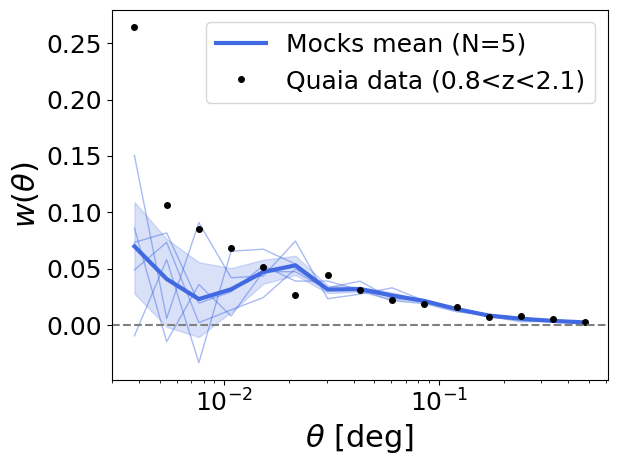

In [7]:
for wtheta_mock in wtheta_mocks:
    plt.plot(theta, wtheta_mock, color='royalblue', lw=1, alpha=0.45)

plt.fill_between(theta, wtheta_p16, wtheta_p84, color='royalblue', alpha=0.2)
plt.plot(theta, wtheta_mean, color='royalblue', lw=3, label=f'Mocks mean (N={len(wtheta_mocks)})')
plt.plot(theta, wtheta_data, color='black', marker='o', linestyle='none', markersize=4, label='Quaia data (0.8<z<2.1)')

plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$w(\theta)$')
plt.xscale('log')
plt.axhline(0, color='grey', linestyle='--')
plt.legend()

# wp(rp)

In [8]:
rng = np.random.default_rng(42)

z_data = tab_data['redshift_quaia']

# Use one shared random-distance assignment so RR(rp,pi) is computed once
z_rand_shared = rng.choice(z_data, size=len(tab_rand), replace=True)

cosmo = astropy.cosmology.Planck18
# Comoving distance in Mpc/h (Corrfunc expects this when is_comoving_dist=True)
# comoving_distance is in Mpc, so to get Mpc/h we need to multiply by h: X Mpc = (X*h) Mpc/h
dist_data = cosmo.comoving_distance(z_data).value * cosmo.h
dist_rand_shared = cosmo.comoving_distance(z_rand_shared).value * cosmo.h

cosmology = 2
is_comoving_dist = True

In [9]:
# rp and pi in Mpc/h (same units as dist passed to compute_wprp)
n_rp_bins = 14
rp_edges_log = np.logspace(np.log10(1), np.log10(200), n_rp_bins + 1)
pimax = 100

In [10]:
# Compute RR(rp,pi) once (shared by data + mocks)
start = time.time()
RR_rp = DDrppi_mocks(1, cosmology, nthreads, pimax, rp_edges_log,
                     ra_rand, dec_rand, dist_rand_shared,
                     is_comoving_dist=is_comoving_dist)
print(f'RR rp time (shared): {time.time()-start:.4f} s')

n_rpbins = len(rp_edges_log) - 1

RR rp time (shared): 114.6198 s


In [11]:
# Real data DD/DR + wp(rp)
start = time.time()
DD_rp_data = DDrppi_mocks(1, cosmology, nthreads, pimax, rp_edges_log,
                          ra_data, dec_data, dist_data,
                          is_comoving_dist=is_comoving_dist)
print(f'DD rp data time: {time.time()-start:.4f} s')

start = time.time()
DR_rp_data = DDrppi_mocks(0, cosmology, nthreads, pimax, rp_edges_log,
                          ra_data, dec_data, dist_data,
                          RA2=ra_rand, DEC2=dec_rand, CZ2=dist_rand_shared,
                          is_comoving_dist=is_comoving_dist)
print(f'DR rp data time: {time.time()-start:.4f} s')

N_data = len(ra_data)
wp_data = convert_rp_pi_counts_to_wp(N_data, N_data, N_rand, N_rand,
                                     DD_rp_data, DR_rp_data,
                                     DR_rp_data, RR_rp, n_rpbins, pimax)

DD rp data time: 2.2645 s
DR rp data time: 25.8879 s


In [12]:
# Mock ensemble measurements (reuse shared RR(rp,pi))
wp_mocks = []
for i, path in enumerate(mock_paths):
    tab_mock_all = Table.read(path)
    mask_z = (tab_mock_all['redshift_quaia'] > zmin) & (tab_mock_all['redshift_quaia'] < zmax)
    tab_mock = tab_mock_all[mask_z]

    ra_mock, dec_mock = tab_mock['ra'], tab_mock['dec']
    z_mock = tab_mock['redshift_quaia']
    dist_mock = cosmo.comoving_distance(z_mock).value * cosmo.h

    start = time.time()
    DD_rp_mock = DDrppi_mocks(1, cosmology, nthreads, pimax, rp_edges_log,
                              ra_mock, dec_mock, dist_mock,
                              is_comoving_dist=is_comoving_dist)
    print(f'Mock {i+1}/{len(mock_paths)} DD rp time: {time.time()-start:.4f} s')

    start = time.time()
    DR_rp_mock = DDrppi_mocks(0, cosmology, nthreads, pimax, rp_edges_log,
                              ra_mock, dec_mock, dist_mock,
                              RA2=ra_rand, DEC2=dec_rand, CZ2=dist_rand_shared,
                              is_comoving_dist=is_comoving_dist)
    print(f'Mock {i+1}/{len(mock_paths)} DR rp time: {time.time()-start:.4f} s')

    N_mock = len(ra_mock)
    wp_mock = convert_rp_pi_counts_to_wp(N_mock, N_mock, N_rand, N_rand,
                                         DD_rp_mock, DR_rp_mock,
                                         DR_rp_mock, RR_rp, n_rpbins, pimax)
    wp_mocks.append(wp_mock)

wp_mocks = np.array(wp_mocks)
wp_mean = np.mean(wp_mocks, axis=0)
wp_p16 = np.percentile(wp_mocks, 16, axis=0)
wp_p84 = np.percentile(wp_mocks, 84, axis=0)

Mock 1/5 DD rp time: 3.7922 s
Mock 1/5 DR rp time: 33.4038 s
Mock 2/5 DD rp time: 1.3746 s
Mock 2/5 DR rp time: 32.4728 s
Mock 3/5 DD rp time: 1.5283 s
Mock 3/5 DR rp time: 27.8157 s
Mock 4/5 DD rp time: 1.5066 s
Mock 4/5 DR rp time: 27.5126 s
Mock 5/5 DD rp time: 1.3975 s
Mock 5/5 DR rp time: 26.1165 s


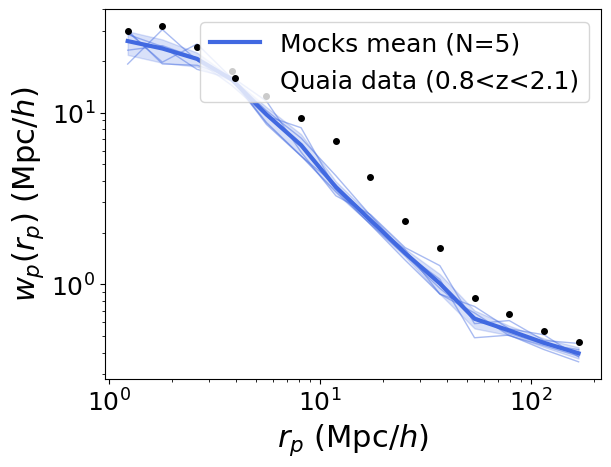

In [13]:
rp_log = (rp_edges_log[1:] + rp_edges_log[:-1]) / 2

for wp_mock in wp_mocks:
    plt.plot(rp_log, wp_mock, color='royalblue', lw=1, alpha=0.45)

plt.fill_between(rp_log, wp_p16, wp_p84, color='royalblue', alpha=0.2)
plt.plot(rp_log, wp_mean, color='royalblue', lw=3, label=f'Mocks mean (N={len(wp_mocks)})')
plt.plot(rp_log, wp_data, color='black', marker='o', linestyle='none', markersize=4, label='Quaia data (0.8<z<2.1)')

plt.xlabel(r'$r_p$ (Mpc/$h$)')
plt.ylabel(r'$w_p(r_p)$ (Mpc/$h$)')
plt.yscale('log')
plt.xscale('log')
plt.legend()